# **1. Análisis Exploratorio de Datos (EDA) Inicial**
### Predicción de la Duración de Viajes en Taxi (NYC) - 3 Meses
Este notebook aborda la exploración inicial de los datos de viajes de taxis amarillos de NYC correspondientes a 3 meses (Enero a Marzo), cubriendo desde la carga hasta la identificación de patrones y detección de anomalías sobre la totalidad del conjunto de datos.

## 1.1. Carga de Datos
Cargamos los datos correspondientes a los primeros 3 meses en un único DataFrame.

In [2]:
#Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
archivos = [f"../data/yellow_tripdata_2026-0{i}.parquet" for i in range (1,4)]
df = pd.concat([pd.read_parquet(f) for f in archivos], ignore_index=True)

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11077201,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,NaN,13,263,0,50.14,0.00,0.5,0.00,0.0,1.0,60.37,NaN,NaN,0.75
11077202,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,NaN,24,42,0,12.32,0.00,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.00
11077203,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,NaN,62,237,0,47.95,0.00,0.5,0.00,0.0,1.0,52.70,NaN,NaN,0.75
11077204,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,NaN,61,141,0,49.93,0.00,0.5,0.00,0.0,1.0,53.93,NaN,NaN,0.00


## 1.2. Número de Filas, Columnas y Tipos de Datos
Revisamos las dimensiones y tipo de dato cada variable.

In [4]:
print("Número total de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número total de filas: 11077206
Número de columnas: 20


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11077206 entries, 0 to 11077205
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64 

In [6]:
# Resumen estadistico descriptivo de variables numericas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,11077206.0,1.876552,1.0,2.0,2.0,2.0,7.0,0.710529
tpep_pickup_datetime,11077206,2026-02-15 16:11:28.931824,2008-12-31 23:03:20,2026-01-24 00:02:16,2026-02-14 21:54:05,2026-03-10 14:52:12,2026-04-01 00:06:25,NaN
tpep_dropoff_datetime,11077206,2026-02-15 16:28:54.533629,2009-01-01 00:07:36,2026-01-24 00:16:40,2026-02-14 22:12:57,2026-03-10 15:13:28,2026-04-02 16:03:47,NaN
passenger_count,8020083.0,1.238929,0.0,1.0,1.0,1.0,9.0,0.646116
trip_distance,11077206.0,6.221664,0.0,1.0,1.8,3.7,328522.2,620.714976
RatecodeID,8020083.0,5.384528,1.0,1.0,1.0,1.0,99.0,20.038324
PULocationID,11077206.0,161.387009,1.0,114.0,161.0,233.0,265.0,66.909506
DOLocationID,11077206.0,160.887215,1.0,107.0,162.0,234.0,265.0,70.9304
payment_type,11077206.0,0.850878,0.0,0.0,1.0,1.0,4.0,0.675896
fare_amount,11077206.0,21.249499,-2555.2,10.0,15.6,26.8,2555.2,18.735194


## 1.3. Porcentaje de Valores Faltantes por Variable
Calculamos el conteo y la proporción de valores nulos por columna sobre la totalidad de los datos.

In [7]:
# Conteo y porcentaje de nulos por columna
faltantes = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
})

faltantes = faltantes.sort_values(by='Porcentaje (%)', ascending=False)
faltantes = faltantes[faltantes['Valores Nulos'] > 0]

faltantes



,Valores Nulos,Porcentaje (%)
passenger_count,3057123,27.598322
congestion_surcharge,3057123,27.598322
store_and_fwd_flag,3057123,27.598322
RatecodeID,3057123,27.598322
Airport_fee,3057123,27.598322


## 1.4. Distribución de la Variable Objetivo (`trip_duration`)
Calculamos la variable objetivo en minutos: `trip_duration = (dropoff - pickup) en minutos`.

In [8]:
# Calculo de la variable objetivo (en minutos)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

print("Estadistica descriptiva de la trip_duration")
print(df['trip_duration'].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

Estadistica descriptiva de la trip_duration
count    1.107721e+07
mean     1.742670e+01
std      2.508609e+01
min     -1.866667e+02
1%       0.000000e+00
5%       3.316667e+00
25%      8.150000e+00
50%      1.353333e+01
75%      2.153333e+01
95%      4.373333e+01
99%      7.323333e+01
max      9.265150e+03
Name: trip_duration, dtype: float64


## 1.5. Visualizaciones Relevantes
Presentamos 5 visualizaciones analizando directamente la totalidad de los datos de los 3 meses.

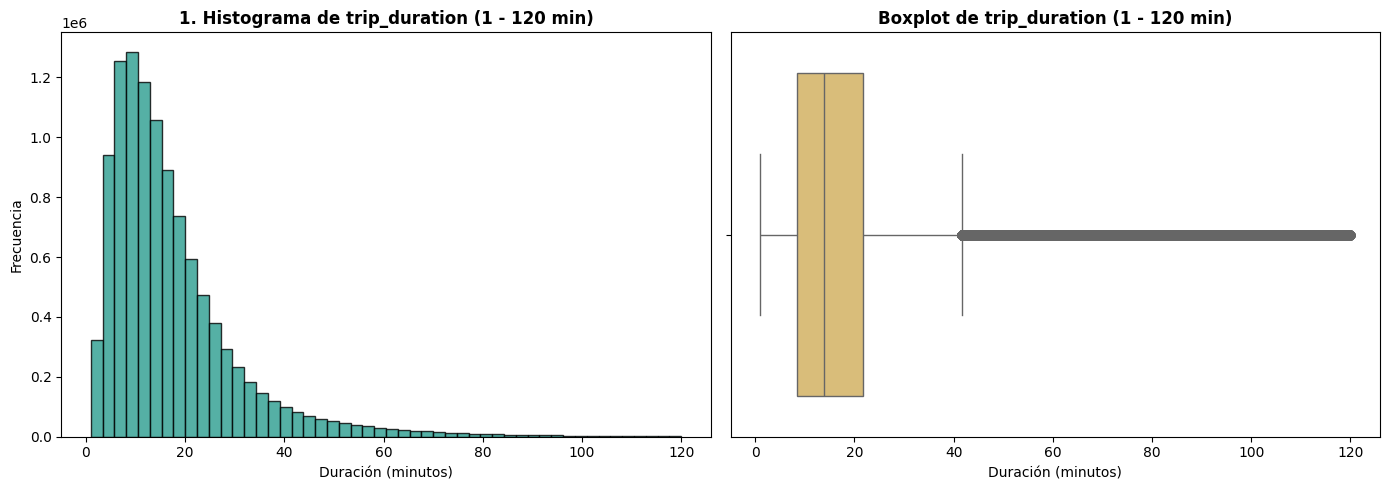

In [9]:
# Visualizacion 1: Distribución de trip_duration (1 a 120 min)
df_dur_filtro = df[(df['trip_duration'] >= 1) & (df['trip_duration'] <= 120)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_dur_filtro['trip_duration'], bins=50, color='#2a9d8f', edgecolor='black', alpha=0.8)
axes[0].set_title('1. Histograma de trip_duration (1 - 120 min)', fontweight='bold')
axes[0].set_xlabel('Duración (minutos)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df_dur_filtro['trip_duration'], ax=axes[1], color='#e9c46a')
axes[1].set_title('Boxplot de trip_duration (1 - 120 min)', fontweight='bold')
axes[1].set_xlabel('Duración (minutos)')

plt.tight_layout()
plt.show()

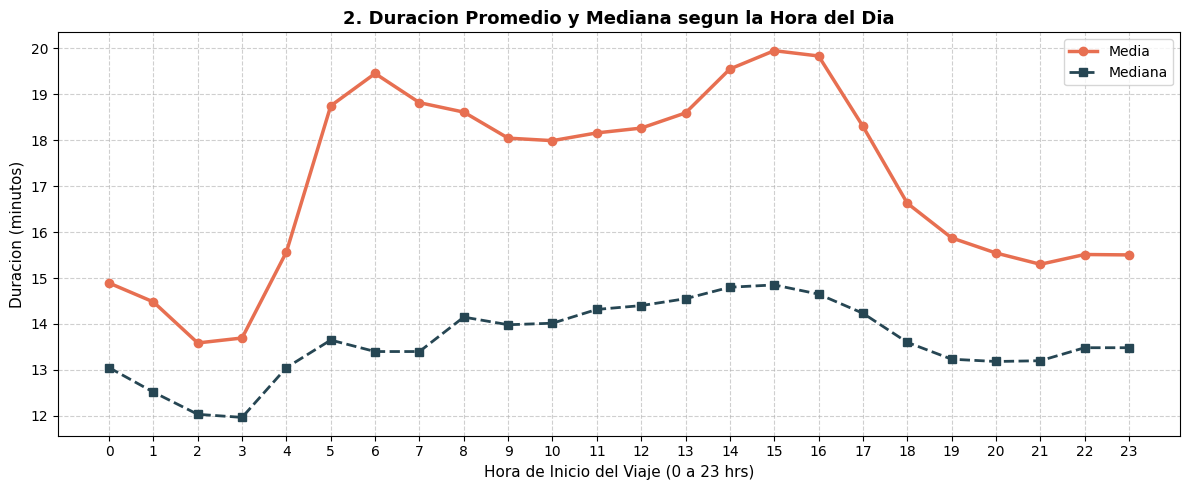

In [10]:
# Visualizacion 2: Patron Horario de la Duración del Viaje (Horas Punta vs Valle)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.day_name()

df_valido = df[(df['trip_duration'] >= 1) & (df['trip_duration'] <= 120)]
hourly_stats = df_valido.groupby('pickup_hour')['trip_duration'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly_stats['pickup_hour'], hourly_stats['mean'], marker='o', color='#e76f51', linewidth=2.5, label='Media')
plt.plot(hourly_stats['pickup_hour'], hourly_stats['median'], marker='s', color='#264653', linewidth=2, linestyle='--', label='Mediana')
plt.title('2. Duracion Promedio y Mediana segun la Hora del Dia', fontsize=13, fontweight='bold')
plt.xlabel('Hora de Inicio del Viaje (0 a 23 hrs)', fontsize=11)
plt.ylabel('Duracion (minutos)', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\axelr\AppData\Local\Temp\ipykernel_10796\3394397277.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


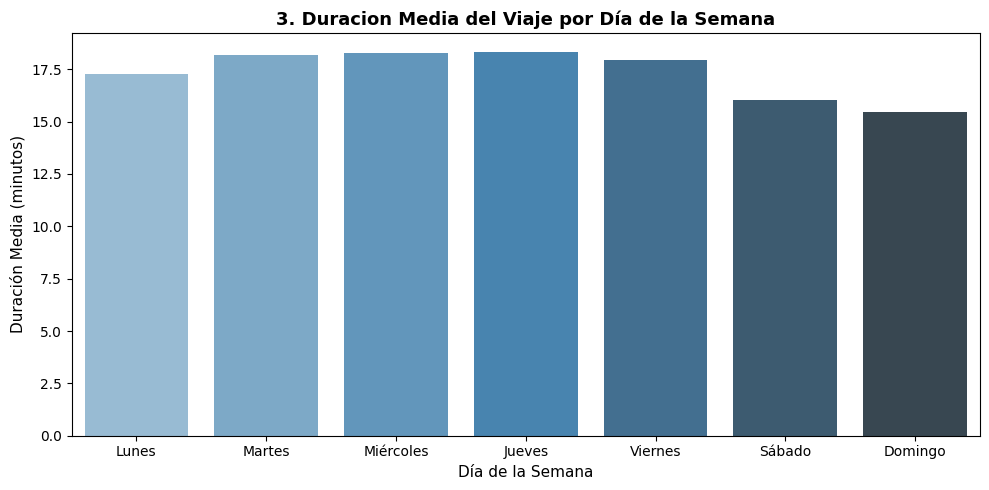

In [11]:
# Visualizacion 3: Duracion Media del Viaje por Día de la Semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_espanol = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

daily_stats = df_valido.groupby('pickup_dayofweek')['trip_duration'].mean().reindex(dias_orden).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=daily_stats,
    x='pickup_dayofweek',
    y='trip_duration',
    palette='Blues_d'
)
plt.title('3. Duracion Media del Viaje por Día de la Semana', fontsize=13, fontweight='bold')
plt.xlabel('Día de la Semana', fontsize=11)
plt.ylabel('Duración Media (minutos)', fontsize=11)
plt.xticks(ticks=range(7), labels=dias_espanol)
plt.tight_layout()
plt.show()

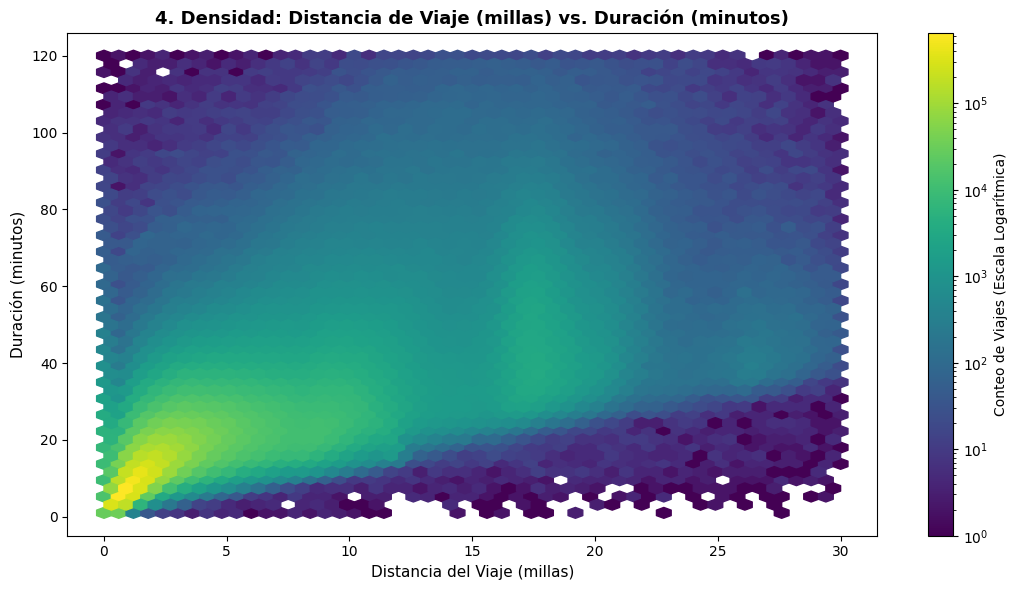

In [12]:
# Visualizacion 4: Densidad 2D entre Distancia de Viaje y Duración (Hexbin)
df_dist_filtro = df_valido[(df_valido['trip_distance'] > 0) & (df_valido['trip_distance'] <= 30)]

plt.figure(figsize=(11, 6))
hb = plt.hexbin(
    df_dist_filtro['trip_distance'],
    df_dist_filtro['trip_duration'],
    gridsize=50,
    cmap='viridis',
    mincnt=1,
    bins='log'
)
cb = plt.colorbar(hb)
cb.set_label('Conteo de Viajes (Escala Logarítmica)')

plt.title('4. Densidad: Distancia de Viaje (millas) vs. Duración (minutos)', fontsize=13, fontweight='bold')
plt.xlabel('Distancia del Viaje (millas)', fontsize=11)
plt.ylabel('Duración (minutos)', fontsize=11)
plt.tight_layout()
plt.show()

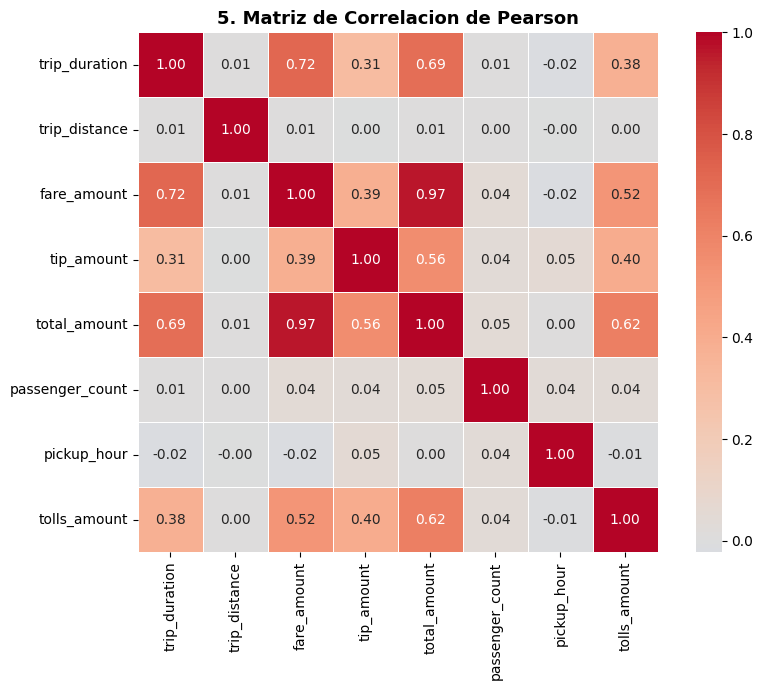

In [13]:
# Visualizacion 5: Matriz de Correlación de Pearson entre Variables Numéricas Relevantes
cols_corr = ['trip_duration', 'trip_distance', 'fare_amount', 'tip_amount', 
             'total_amount', 'passenger_count', 'pickup_hour', 'tolls_amount']
cols_disponibles = [c for c in cols_corr if c in df_valido.columns]

corr_matrix = df_valido[cols_disponibles].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('5. Matriz de Correlacion de Pearson', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.6. Identificación de Outliers y Registros Sospechosos
Auditamos cuantitativamente las anomalías operativas y valores atípicos sobre la totalidad de los datos (3 meses).

In [14]:
total_filas = len(df)

condiciones_outliers = {
    'Duracion <= 0 min (Errores de timestamp)': (df['trip_duration'] <= 0).sum(),
    'Duracion > 180 min (> 3 horas - viajes no cerrados)': (df['trip_duration'] > 180).sum(),
    'Distancia == 0 y Duracion > 5 min (Viaje estatico)': ((df['trip_distance'] == 0) & (df['trip_duration'] > 5)).sum(),
    'Distancia > 100 millas (Distancia extrema no urbana)': (df['trip_distance'] > 100).sum(),
    'Pasajeros == 0 o > 6 (Capacidad irregular)': ((df['passenger_count'] == 0) | (df['passenger_count'] > 6)).sum(),
    'Tarifa o Monto Total Negativo (Reembolsos/Cancelaciones)': ((df['fare_amount'] < 0) | (df['total_amount'] < 0)).sum()
}

df_outliers_reporte = pd.DataFrame([
    {
        'Tipo de Anomalía / Outlier': k,
        'Cantidad de Registros': v,
        'Porcentaje del Total (%)': (v / total_filas) * 100
    }
    for k, v in condiciones_outliers.items()
])

print("--- Auditoría Cuantitativa de Outliers y Registros Sospechosos (3 Meses) ---")
display(df_outliers_reporte)

--- Auditoría Cuantitativa de Outliers y Registros Sospechosos (3 Meses) ---


,Tipo de Anomalía / Outlier,Cantidad de Registros,Porcentaje del Total (%)
0,Duracion <= 0 min (Errores de timestamp),134801,1.216922
1,Duracion > 180 min (> 3 horas - viajes no cerr...,4464,0.040299
2,Distancia == 0 y Duracion > 5 min (Viaje estat...,275407,2.486250
3,Distancia > 100 millas (Distancia extrema no u...,495,0.004469
4,Pasajeros == 0 o > 6 (Capacidad irregular),40652,0.366988
5,Tarifa o Monto Total Negativo (Reembolsos/Canc...,88623,0.800048


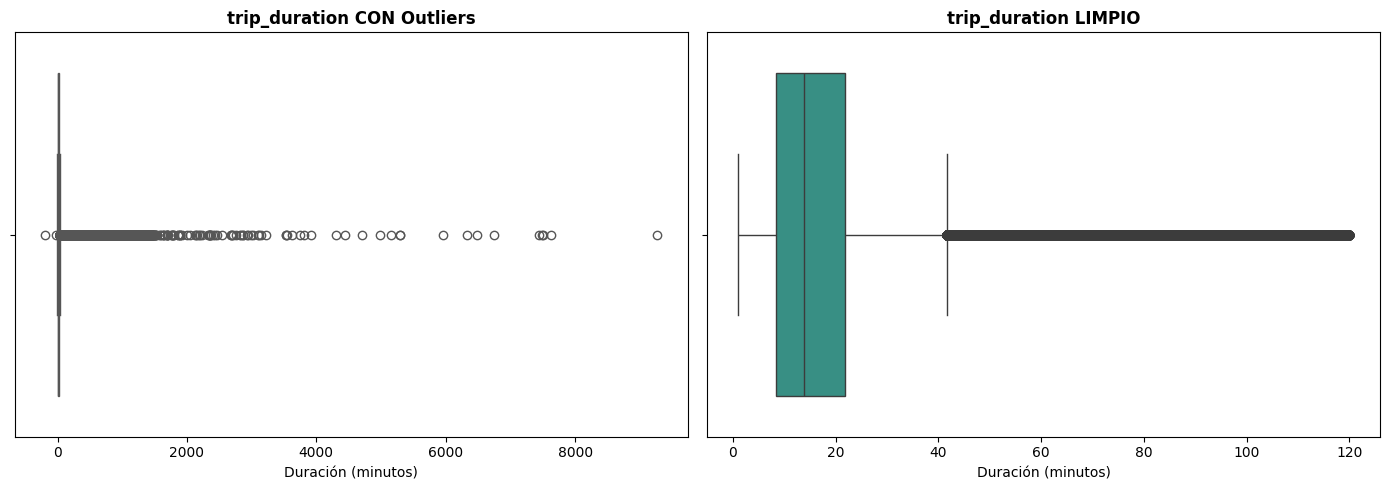

In [15]:
# Visualización del impacto del filtrado de outliers en trip_duration (3 Meses)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers extremos (sin filtro)
sns.boxplot(x=df['trip_duration'], ax=axes[0], color='#e63946')
axes[0].set_title('trip_duration CON Outliers', fontweight='bold')
axes[0].set_xlabel('Duración (minutos)')

# Sin outliers (filtrado: 1 a 120 min)
sns.boxplot(x=df_valido['trip_duration'], ax=axes[1], color='#2a9d8f')
axes[1].set_title('trip_duration LIMPIO', fontweight='bold')
axes[1].set_xlabel('Duración (minutos)')

plt.tight_layout()
plt.show()